In [ ]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

In [ ]:
parent_folder_ICOB_project = os.get.cwd()

### see diversity and elite fitness over generations - standard GA

In [ ]:
folder_path = parent_folder_ICOB_project + 'GA\\logs_with_best_params\\'

In [ ]:
# Get all .txt file paths in the folder
file_paths = glob.glob(os.path.join(folder_path, "*.txt"))

# Load each file into a DataFrame and store in a list
dataframes = [pd.read_csv(file, sep=",") for file in file_paths] 

# Concatenate all DataFrames into one
combined_df = pd.concat(dataframes, ignore_index=True)
combined_standard = combined_df

# Group by generation and calculate mean of best_fitness and diversity
average_standard_df = combined_standard.groupby('generation')[['best_fitness', 'diversity']].median().reset_index()

# Rename columns for clarity
average_standard_df.columns = ['generation', 'median_best_fitness', 'median_diversity']

# Done! Here's your aggregated DataFrame
print(average_standard_df.head())

   generation  median_best_fitness  median_diversity
0           0           551.822857       8948.704252
1           1           510.300102     231667.065914
2           2           348.667033     212882.913862
3           3           212.943829     208820.653233
4           4           195.311459     221589.543191


In [ ]:
### get fitness values for last elites of each run 
standard_GA_last_elites = []

for run in dataframes:
    best_fitness_last = run.iloc[-1]['best_fitness']
    standard_GA_last_elites.append(best_fitness_last)
    
print(standard_GA_last_elites)

[12.02738904310172, 10.426354563046887, 13.1621114425312, 13.024580276450456, 12.30891693149761, 10.727402357863836, 10.07230021903175, 10.588136520208948, 9.742481848119615, 10.444124328528009]


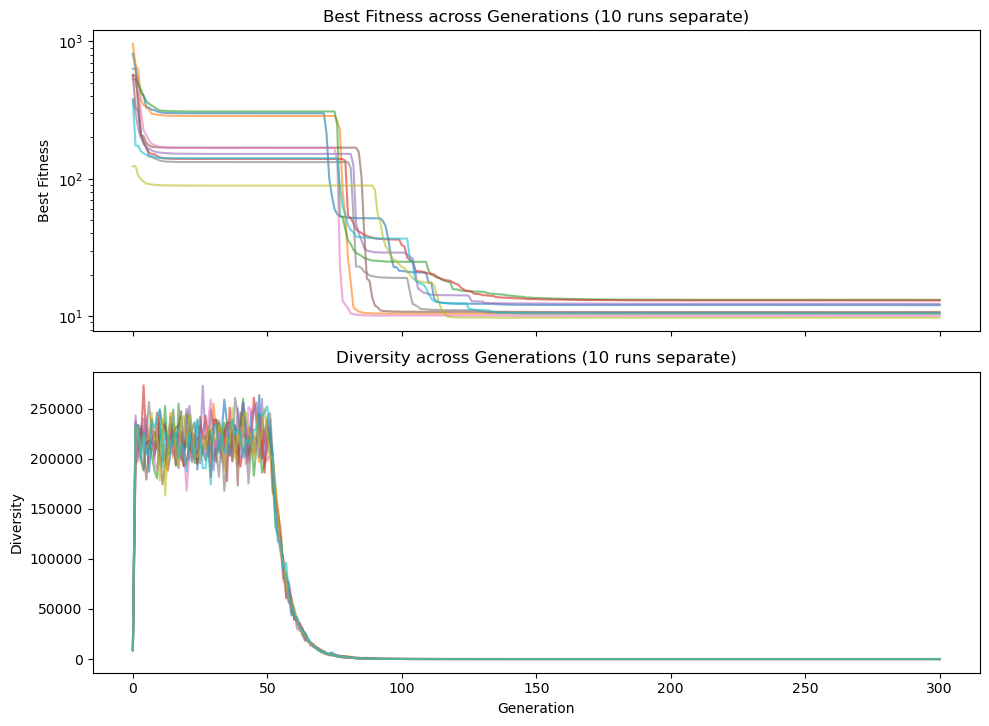

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


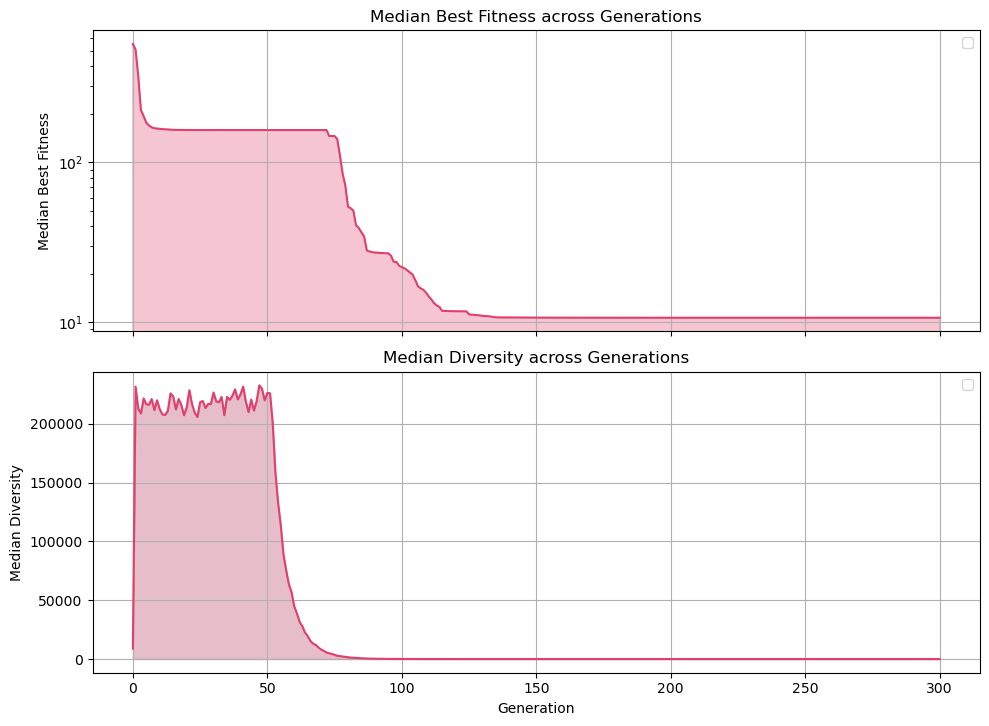

In [ ]:
# -------- Plot 1: Individual Runs --------
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for df in dataframes:
    ax1.plot(df['generation'], df['best_fitness'], alpha=0.6)
    ax2.plot(df['generation'], df['diversity'], alpha=0.6)

ax1.set_yscale('log')
ax1.set_ylabel("Best Fitness")
ax2.set_ylabel("Diversity")
ax2.set_xlabel("Generation")

ax1.set_title("Best Fitness across Generations (10 runs separate)")
ax2.set_title("Diversity across Generations (10 runs separate)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# -------- Plot 2: Median runs --------
fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot median best fitness with fill
ax3.plot(average_standard_df['generation'], average_standard_df['median_best_fitness'], color='#e13f6d')
ax3.fill_between(average_standard_df['generation'], average_standard_df['median_best_fitness'], color='#e13f6d', alpha=0.3)
ax3.set_yscale('log')
ax3.set_ylabel("Median Best Fitness")
ax3.set_title("Median Best Fitness across Generations")
ax3.grid(True)
ax3.legend()

# Plot median diversity with fill
ax4.plot(average_standard_df['generation'], average_standard_df['median_diversity'], color='#e13f6d')
ax4.fill_between(average_standard_df['generation'], average_standard_df['median_diversity'], color='#ad284e', alpha=0.3)
ax4.set_ylabel("Median Diversity")
ax4.set_xlabel("Generation")
ax4.set_title("Median Diversity across Generations")
ax4.grid(True)
ax4.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


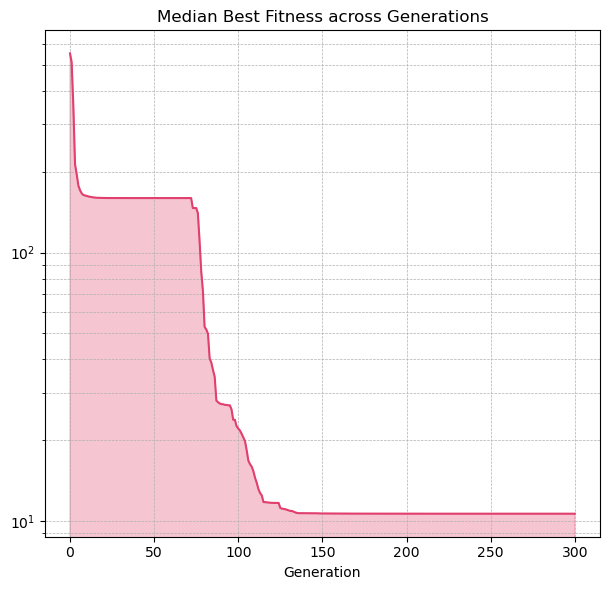

In [ ]:
import matplotlib.pyplot as plt

# Assuming average_standard_df is already defined and contains the required columns

fig, ax3 = plt.subplots(figsize=(6.2, 6))

# Plot line
ax3.plot(
    average_standard_df['generation'], 
    average_standard_df['median_best_fitness'], 
    color='#e13f6d', 
    label='Median Best Fitness'
)

# Fill between for the area under the curve
ax3.fill_between(
    average_standard_df['generation'], 
    average_standard_df['median_best_fitness'], 
    color='#e13f6d', 
    alpha=0.3
)

# Log scale for y-axis
ax3.set_yscale('log')

# Axis labels and title
ax3.set_xlabel("Generation")
ax3.set_title("Median Best Fitness across Generations")

# Grid and legend
ax3.grid(True, which="both", ls="--", linewidth=0.5)

# Show the plot
plt.tight_layout()
plt.show()


### see diversity and elite fitness over generations - egalitarian extinction GAs

In [ ]:
folder_path = parent_folder_ICOB_project + 'GA_extinctions\\logs_with_best_params\\'

In [ ]:
# Get all .txt file paths starting with "egalitarian"
file_paths = glob.glob(os.path.join(folder_path, "egalitarian*.txt"))

# Load each file into a DataFrame and store in a list
dataframes = [pd.read_csv(file, sep=",") for file in file_paths if os.path.getsize(file) > 0]

# Concatenate all DataFrames into one
combined_egalitarian = pd.concat(dataframes, ignore_index=True)

# Group by generation and calculate median of best_fitness and diversity
average_egalitarian_df = combined_egalitarian.groupby('generation')[['best_fitness', 'diversity']].median().reset_index()

# Rename columns for clarity
average_egalitarian_df.columns = ['generation', 'median_best_fitness', 'median_diversity']

# Done! Here's your aggregated DataFrame
print(average_egalitarian_df.tail())

     generation  median_best_fitness  median_diversity
296         296            20.519582      2.467550e-12
297         297            20.519582      2.118025e-12
298         298            20.519582      1.885221e-12
299         299            20.519582      1.559667e-12
300         300            20.519582      1.405527e-12


In [ ]:
### get fitness values for last elites of each run 
egalitarian_GA_last_elites = []

for run in dataframes:
    best_fitness_last = run.iloc[-1]['best_fitness']
    egalitarian_GA_last_elites.append(best_fitness_last)
    
print(egalitarian_GA_last_elites)

[22.76472851086612, 18.79796972561881, 19.7943967333285, 22.455885809559284, 11.80152968743992, 15.434159977438677, 27.45591204329617, 45.05080198784659, 21.244767890502885, 14.569421776444656]


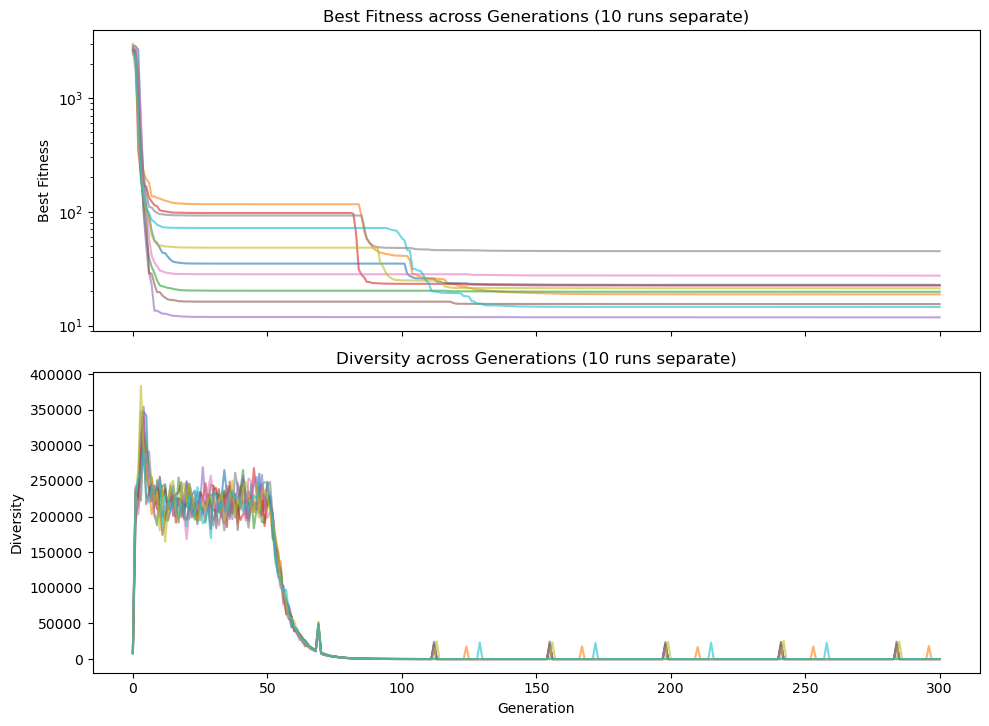

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


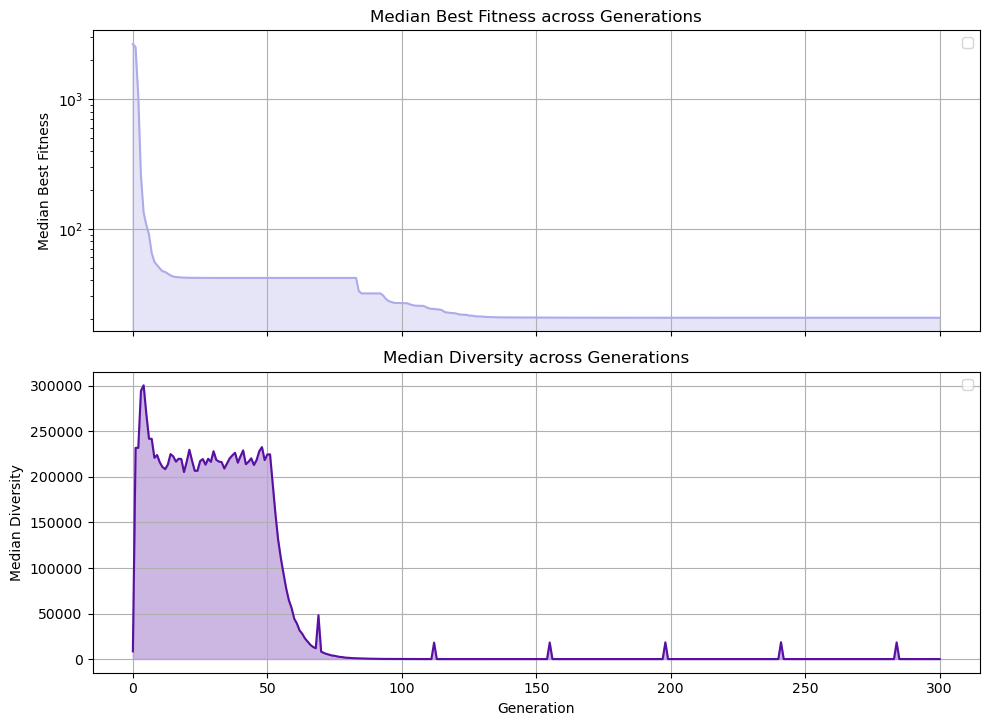

In [ ]:
# -------- Plot 1: Individual Runs --------
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for df in dataframes:
    ax1.plot(df['generation'], df['best_fitness'], alpha=0.6)
    ax2.plot(df['generation'], df['diversity'], alpha=0.6)

ax1.set_yscale('log')
ax1.set_ylabel("Best Fitness")
ax2.set_ylabel("Diversity")
ax2.set_xlabel("Generation")

ax1.set_title("Best Fitness across Generations (10 runs separate)")
ax2.set_title("Diversity across Generations (10 runs separate)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# -------- Plot 2: Median runs --------
fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot median best fitness with fill
ax3.plot(average_egalitarian_df['generation'], average_egalitarian_df['median_best_fitness'], color='#aeabeb')
ax3.fill_between(average_egalitarian_df['generation'], average_egalitarian_df['median_best_fitness'], color='#aeabeb', alpha=0.3)
ax3.set_yscale('log')
ax3.set_ylabel("Median Best Fitness")
ax3.set_title("Median Best Fitness across Generations")
ax3.grid(True)
ax3.legend()

# Plot median diversity with fill
ax4.plot(average_egalitarian_df['generation'], average_egalitarian_df['median_diversity'], color='#5810a2')
ax4.fill_between(average_egalitarian_df['generation'], average_egalitarian_df['median_diversity'], color='#5810a2', alpha=0.3)
ax4.set_ylabel("Median Diversity")
ax4.set_xlabel("Generation")
ax4.set_title("Median Diversity across Generations")
ax4.grid(True)
ax4.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
# Get all .txt file paths starting with "elite"
file_paths = glob.glob(os.path.join(folder_path, "elite*.txt"))

# Load each file into a DataFrame and store in a list
dataframes = [pd.read_csv(file, sep=",") for file in file_paths if os.path.getsize(file) > 0]

# Concatenate all DataFrames into one
combined_elite = pd.concat(dataframes, ignore_index=True)

# Group by generation and calculate median of best_fitness and diversity
average_elite_df = combined_elite.groupby('generation')[['best_fitness', 'diversity']].median().reset_index()

# Rename columns for clarity
average_elite_df.columns = ['generation', 'median_best_fitness', 'median_diversity']

# Done! Here's your aggregated DataFrame
print(average_elite_df.tail())

     generation  median_best_fitness  median_diversity
296         296            20.276736      2.579034e-12
297         297            20.276736      1.893042e-12
298         298            20.276736      1.522503e-12
299         299            20.276736      1.313475e-12
300         300            20.276736      1.224144e-12


In [ ]:
### get fitness values for last elites of each run 
elite_GA_last_elites = []

for run in dataframes:
    best_fitness_last = run.iloc[-1]['best_fitness']
    elite_GA_last_elites.append(best_fitness_last)
    
print(elite_GA_last_elites)

[23.26767114392123, 15.724973262225848, 19.79504456814601, 21.911502572067736, 11.798998867849102, 15.439035046452352, 27.457636064116347, 44.57161987204678, 20.75842701326722, 14.88839367330642]


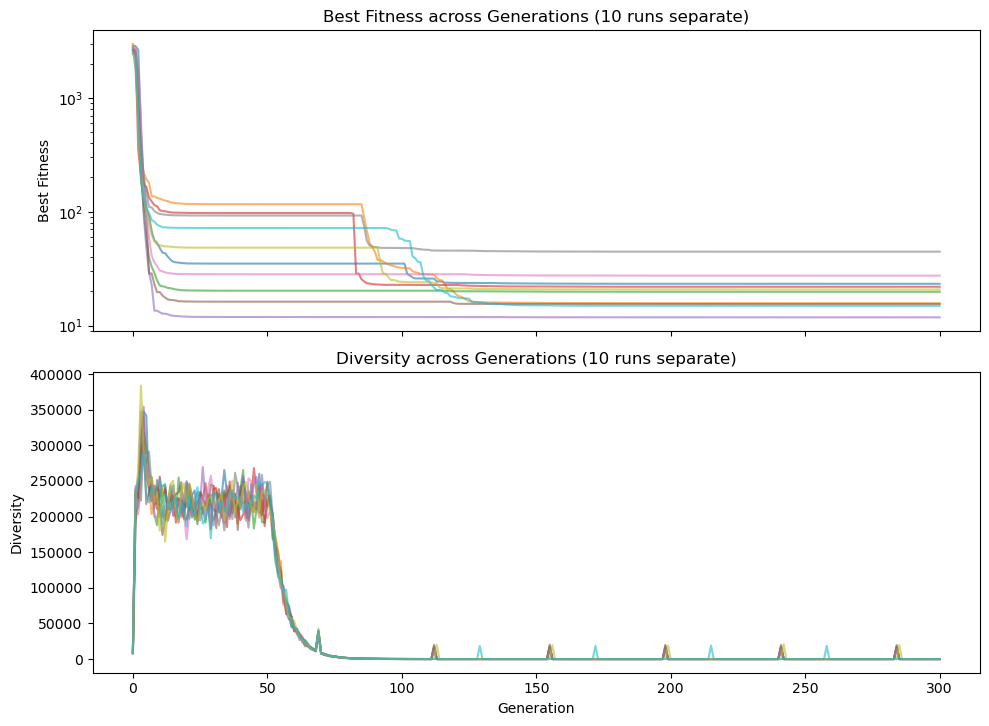

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


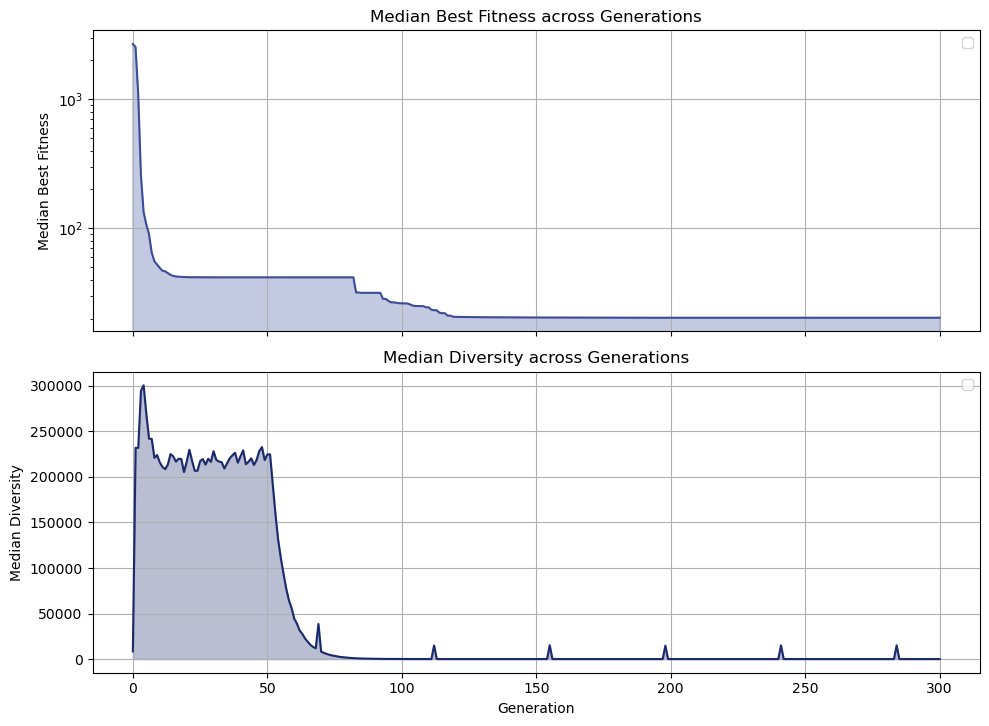

In [ ]:
# -------- Plot 1: Individual Runs --------
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for df in dataframes:
    ax1.plot(df['generation'], df['best_fitness'], alpha=0.6)
    ax2.plot(df['generation'], df['diversity'], alpha=0.6)

ax1.set_yscale('log')
ax1.set_ylabel("Best Fitness")
ax2.set_ylabel("Diversity")
ax2.set_xlabel("Generation")

ax1.set_title("Best Fitness across Generations (10 runs separate)")
ax2.set_title("Diversity across Generations (10 runs separate)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# -------- Plot 2: Median runs --------
fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot median best fitness with fill
ax3.plot(average_elite_df['generation'], average_elite_df['median_best_fitness'], color='#3b4d99')
ax3.fill_between(average_elite_df['generation'], average_elite_df['median_best_fitness'], color='#3b4d99', alpha=0.3)
ax3.set_yscale('log')
ax3.set_ylabel("Median Best Fitness")
ax3.set_title("Median Best Fitness across Generations")
ax3.grid(True)
ax3.legend()

# Plot median diversity with fill
ax4.plot(average_elite_df['generation'], average_elite_df['median_diversity'], color='#1a2a6c')
ax4.fill_between(average_elite_df['generation'], average_elite_df['median_diversity'], color='#1a2a6c', alpha=0.3)
ax4.set_ylabel("Median Diversity")
ax4.set_xlabel("Generation")
ax4.set_title("Median Diversity across Generations")
ax4.grid(True)
ax4.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
# Get all .txt file paths starting with "weirdo"
file_paths = glob.glob(os.path.join(folder_path, "weirdo*.txt"))

# Load each file into a DataFrame and store in a list
dataframes = [pd.read_csv(file, sep=",") for file in file_paths if os.path.getsize(file) > 0]

# Concatenate all DataFrames into one
combined_weirdo = pd.concat(dataframes, ignore_index=True)

# Group by generation and calculate median of best_fitness and diversity
average_weirdo_df = combined_weirdo.groupby('generation')[['best_fitness', 'diversity']].median().reset_index()

# Rename columns for clarity
average_weirdo_df.columns = ['generation', 'median_best_fitness', 'median_diversity']

# Done! Here's your aggregated DataFrame
print(average_weirdo_df.tail())

     generation  median_best_fitness  median_diversity
296         296            20.268712      2.737460e-12
297         297            20.268712      2.108217e-12
298         298            20.268712      1.778450e-12
299         299            20.268712      1.547658e-12
300         300            20.268712      1.255668e-12


In [ ]:
### get fitness values for last elites of each run 
weirdo_GA_last_elites = []

for run in dataframes:
    best_fitness_last = run.iloc[-1]['best_fitness']
    weirdo_GA_last_elites.append(best_fitness_last)
    
print(weirdo_GA_last_elites)

[23.34390813700355, 15.663370756992052, 19.795156636939037, 21.9087274023558, 11.792971169778417, 15.440724642749291, 27.457810927622457, 44.714226506594215, 20.742267507900397, 14.885527429998715]


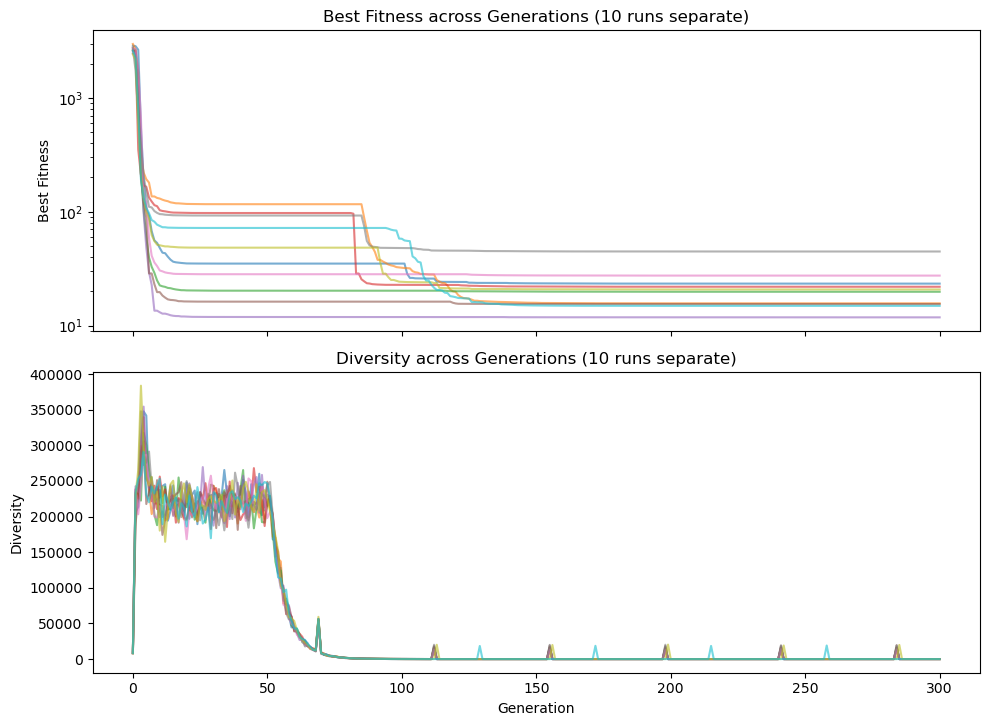

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


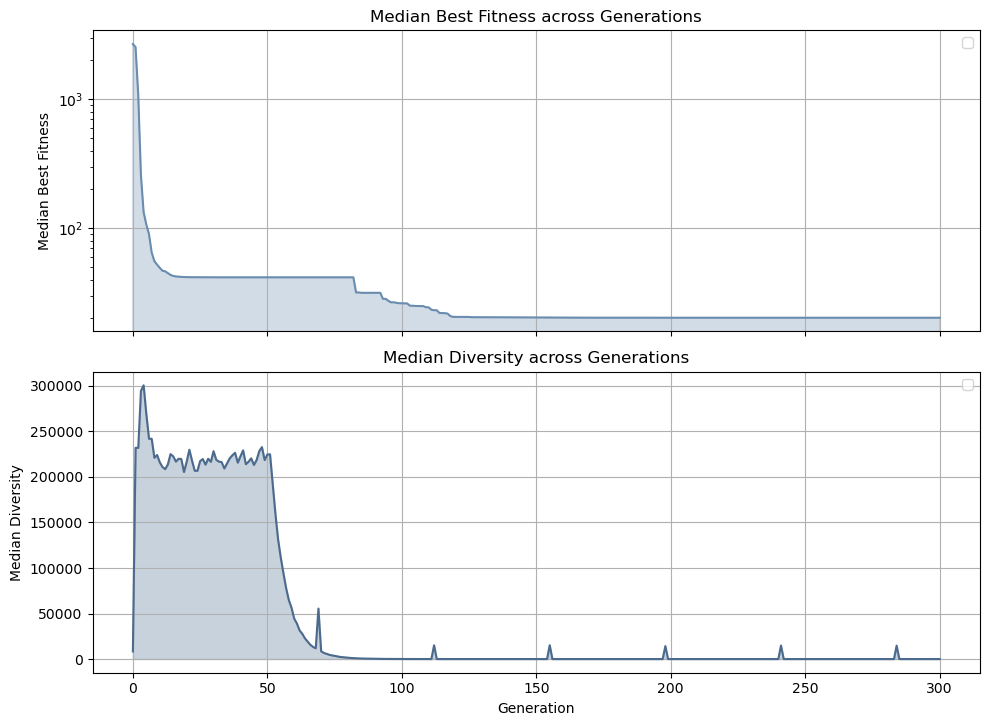

In [ ]:
# -------- Plot 1: Individual Runs --------
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for df in dataframes:
    ax1.plot(df['generation'], df['best_fitness'], alpha=0.6)
    ax2.plot(df['generation'], df['diversity'], alpha=0.6)

ax1.set_yscale('log')
ax1.set_ylabel("Best Fitness")
ax2.set_ylabel("Diversity")
ax2.set_xlabel("Generation")

ax1.set_title("Best Fitness across Generations (10 runs separate)")
ax2.set_title("Diversity across Generations (10 runs separate)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# -------- Plot 2: Median runs --------
fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot median best fitness with fill
ax3.plot(average_weirdo_df['generation'], average_weirdo_df['median_best_fitness'], color='#6A8CAF')
ax3.fill_between(average_weirdo_df['generation'], average_weirdo_df['median_best_fitness'], color='#6A8CAF', alpha=0.3)
ax3.set_yscale('log')
ax3.set_ylabel("Median Best Fitness")
ax3.set_title("Median Best Fitness across Generations")
ax3.grid(True)
ax3.legend()

# Plot median diversity with fill
ax4.plot(average_weirdo_df['generation'], average_weirdo_df['median_diversity'], color='#4B6A8D')
ax4.fill_between(average_weirdo_df['generation'], average_weirdo_df['median_diversity'], color='#4B6A8D', alpha=0.3)
ax4.set_ylabel("Median Diversity")
ax4.set_xlabel("Generation")
ax4.set_title("Median Diversity across Generations")
ax4.grid(True)
ax4.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Get all .txt file paths starting with "immigrant"
file_paths = glob.glob(os.path.join(folder_path, "immigrant*.txt"))

# Load each file into a DataFrame and store in a list
dataframes = [pd.read_csv(file, sep=",") for file in file_paths if os.path.getsize(file) > 0]

# Concatenate all DataFrames into one
combined_df = pd.concat(dataframes, ignore_index=True)
combined_immigrant = combined_df

# Group by generation and calculate median of best_fitness and diversity
average_immigrant_df = combined_df.groupby('generation')[['best_fitness', 'diversity']].median().reset_index()

# Rename columns for clarity
average_immigrant_df.columns = ['generation', 'median_best_fitness', 'median_diversity']

# Done! Here's your aggregated DataFrame
print(average_immigrant_df.tail())

     generation  median_best_fitness  median_diversity
296         296            20.607373      2.101601e-12
297         297            20.607373      1.944231e-12
298         298            20.607372      1.769458e-12
299         299            20.607372      1.395844e-12
300         300            20.607372      1.331046e-12


In [ ]:
### get fitness values for last elites of each run 
immigrant_GA_last_elites = []

for run in dataframes:
    best_fitness_last = run.iloc[-1]['best_fitness']
    immigrant_GA_last_elites.append(best_fitness_last)
    
print(immigrant_GA_last_elites)

[23.411492197482364, 16.26135539315544, 19.799318915897548, 22.024806434748125, 11.797432963774584, 15.446901330222133, 27.45138999567676, 44.93928793962269, 21.41542590748176, 14.353688633832078]


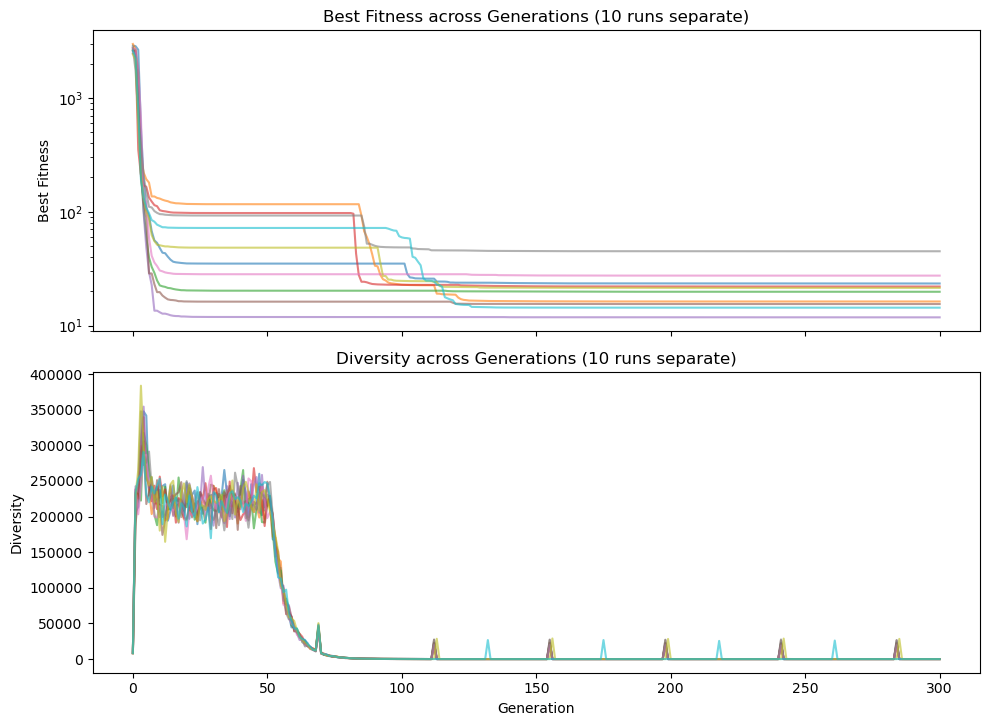

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


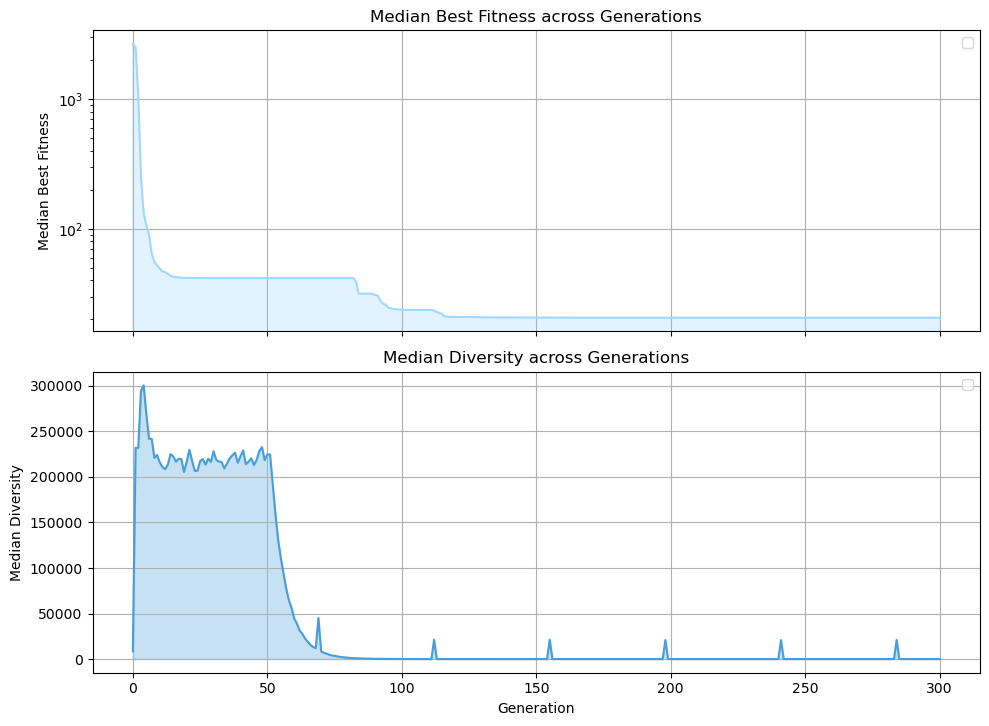

In [ ]:
# -------- Plot 1: Individual Runs --------
fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for df in dataframes:
    ax1.plot(df['generation'], df['best_fitness'], alpha=0.6)
    ax2.plot(df['generation'], df['diversity'], alpha=0.6)

ax1.set_yscale('log')
ax1.set_ylabel("Best Fitness")
ax2.set_ylabel("Diversity")
ax2.set_xlabel("Generation")

ax1.set_title("Best Fitness across Generations (10 runs separate)")
ax2.set_title("Diversity across Generations (10 runs separate)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# -------- Plot 2: Median runs --------
fig2, (ax3, ax4) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot median best fitness with fill
ax3.plot(average_immigrant_df['generation'], average_immigrant_df['median_best_fitness'], color='#a1d8ff')
ax3.fill_between(average_immigrant_df['generation'], average_immigrant_df['median_best_fitness'], color='#a1d8ff', alpha=0.3)
ax3.set_yscale('log')
ax3.set_ylabel("Median Best Fitness")
ax3.set_title("Median Best Fitness across Generations")
ax3.grid(True)
ax3.legend()

# Plot median diversity with fill
ax4.plot(average_immigrant_df['generation'], average_immigrant_df['median_diversity'], color='#479EDB')
ax4.fill_between(average_immigrant_df['generation'], average_immigrant_df['median_diversity'], color='#479EDB', alpha=0.3)
ax4.set_ylabel("Median Diversity")
ax4.set_xlabel("Generation")
ax4.set_title("Median Diversity across Generations")
ax4.grid(True)
ax4.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### all models on a plot median diversity and median best fitness

In [ ]:
average_standard_df.tail()

,generation,median_best_fitness,median_diversity
296,296,10.657770,2.214040e-12
297,297,10.657769,1.888351e-12
298,298,10.657769,1.626351e-12
299,299,10.657769,1.508278e-12
300,300,10.657769,1.274961e-12


In [ ]:
average_egalitarian_df.tail()

,generation,median_best_fitness,median_diversity
296,296,20.519582,2.467550e-12
297,297,20.519582,2.118025e-12
298,298,20.519582,1.885221e-12
299,299,20.519582,1.559667e-12
300,300,20.519582,1.405527e-12


In [ ]:
average_elite_df.tail()

,generation,median_best_fitness,median_diversity
296,296,20.276736,2.579034e-12
297,297,20.276736,1.893042e-12
298,298,20.276736,1.522503e-12
299,299,20.276736,1.313475e-12
300,300,20.276736,1.224144e-12


In [ ]:
average_weirdo_df.tail()

,generation,median_best_fitness,median_diversity
296,296,20.268712,2.737460e-12
297,297,20.268712,2.108217e-12
298,298,20.268712,1.778450e-12
299,299,20.268712,1.547658e-12
300,300,20.268712,1.255668e-12


In [ ]:
average_immigrant_df.tail()

,generation,median_best_fitness,median_diversity
296,296,20.607373,2.101601e-12
297,297,20.607373,1.944231e-12
298,298,20.607372,1.769458e-12
299,299,20.607372,1.395844e-12
300,300,20.607372,1.331046e-12


In [ ]:
# List of your dataframes
dfs = [average_standard_df, average_egalitarian_df, average_elite_df, average_weirdo_df, average_immigrant_df]

# Define separate custom colors
fitness_colors = ['#e13f6d', '#aeabeb', '#3b4d99', '#6A8CAF', '#a1d8ff']        # Colors for fitness plot
diversity_colors = ['#ad284e', '#5810a2', '#1a2a6c', '#4B6A8D', '#479EDB']    # Colors for diversity plot

# Custom labels
labels = ['standard GA', 'egalitarian GA', 'elite GA', 'weirdo GA', 'immigrant GA']

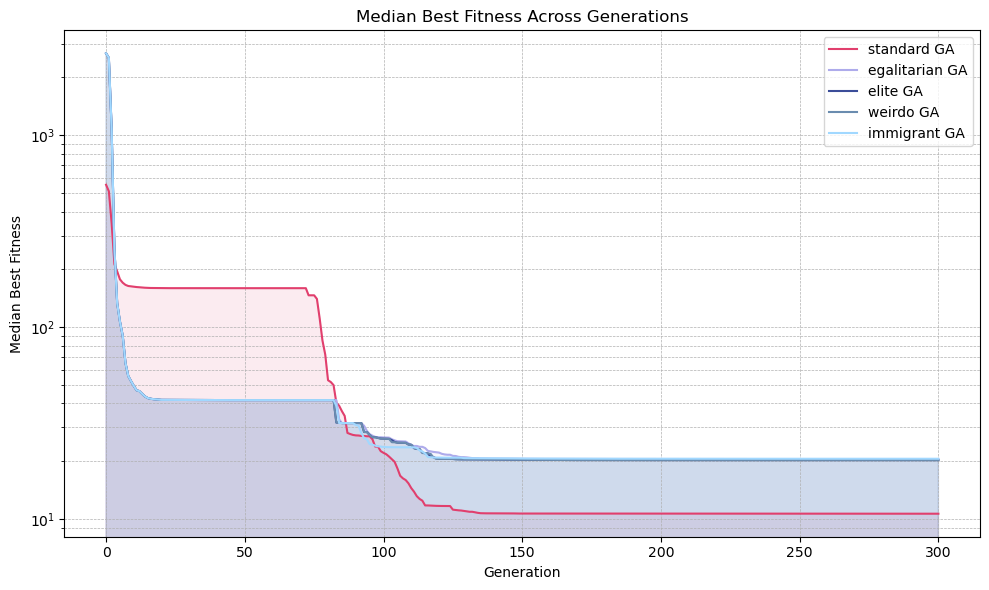

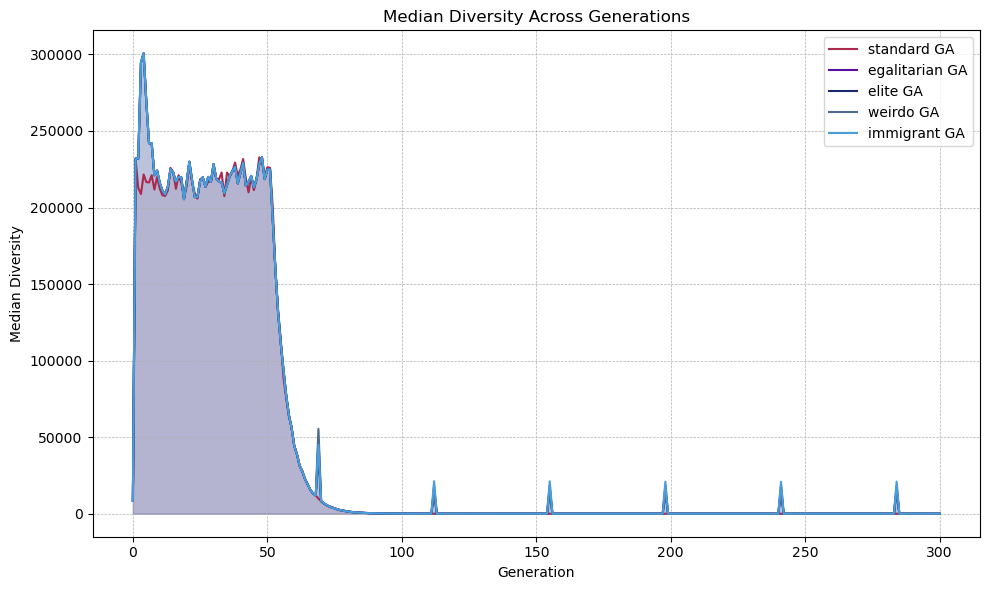

In [ ]:
# --- Fitness plot with log y-axis ---
plt.figure(figsize=(10, 6))
for df, color, label in zip(dfs, fitness_colors, labels):
    plt.plot(df['generation'], df['median_best_fitness'], label=label, color=color)
    plt.fill_between(df['generation'], df['median_best_fitness'], alpha=0.1, color=color)
plt.xlabel('Generation')
plt.ylabel('Median Best Fitness')
plt.title('Median Best Fitness Across Generations')
plt.yscale('log')  # Log scale for y-axis
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# --- Diversity plot with standard scale ---
plt.figure(figsize=(10, 6))
for df, color, label in zip(dfs, diversity_colors, labels):
    plt.plot(df['generation'], df['median_diversity'], label=label, color=color)
    plt.fill_between(df['generation'], df['median_diversity'], alpha=0.1, color=color)
plt.xlabel('Generation')
plt.ylabel('Median Diversity')
plt.title('Median Diversity Across Generations')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


### statistically compare the last elites of each model

In [ ]:
print(standard_GA_last_elites)
print(elite_GA_last_elites)
print(egalitarian_GA_last_elites)
print(weirdo_GA_last_elites)
print(immigrant_GA_last_elites)

[12.02738904310172, 10.426354563046887, 13.1621114425312, 13.024580276450456, 12.30891693149761, 10.727402357863836, 10.07230021903175, 10.588136520208948, 9.742481848119615, 10.444124328528009]
[23.26767114392123, 15.724973262225848, 19.79504456814601, 21.911502572067736, 11.798998867849102, 15.439035046452352, 27.457636064116347, 44.57161987204678, 20.75842701326722, 14.88839367330642]
[22.76472851086612, 18.79796972561881, 19.7943967333285, 22.455885809559284, 11.80152968743992, 15.434159977438677, 27.45591204329617, 45.05080198784659, 21.244767890502885, 14.569421776444656]
[23.34390813700355, 15.663370756992052, 19.795156636939037, 21.9087274023558, 11.792971169778417, 15.440724642749291, 27.457810927622457, 44.714226506594215, 20.742267507900397, 14.885527429998715]
[23.411492197482364, 16.26135539315544, 19.799318915897548, 22.024806434748125, 11.797432963774584, 15.446901330222133, 27.45138999567676, 44.93928793962269, 21.41542590748176, 14.353688633832078]


### Kruskall wallis for all against all comparison

In [ ]:
from scipy.stats import kruskal

h_stat, p_value = kruskal(standard_GA_last_elites, elite_GA_last_elites, egalitarian_GA_last_elites, weirdo_GA_last_elites, immigrant_GA_last_elites)
print(f"Kruskal–Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Kruskal–Wallis H-statistic: 19.9294
P-value: 0.0005


### Pairwise MWU

In [ ]:
from scipy.stats import mannwhitneyu
from itertools import combinations
import pandas as pd
from statsmodels.stats.multitest import multipletests

# Lists and names
group_lists = [standard_GA_last_elites, egalitarian_GA_last_elites, elite_GA_last_elites, weirdo_GA_last_elites, immigrant_GA_last_elites]
group_names = ['standard GA', 'egalitarian GA', 'elite GA', 'weirdo GA', 'immigrant GA']

# Mann-Whitney U test for all pairwise comparisons
results = []
for (i, group1), (j, group2) in combinations(enumerate(group_lists), 2):
    stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
    results.append({
        'Group 1': group_names[i],
        'Group 2': group_names[j],
        'Raw p-value': p
    })

# Put results in DataFrame
df_results = pd.DataFrame(results)

# FDR (Benjamini–Hochberg) correction
raw_pvals = df_results['Raw p-value'].values
rejected, pvals_corrected, _, _ = multipletests(raw_pvals, method='fdr_bh')
df_results['FDR-corrected p-value'] = pvals_corrected
df_results['Significant (FDR p < 0.05)'] = rejected

# Bonferroni correction
n_comparisons = len(df_results)
df_results['Corrected p-value'] = df_results['Raw p-value'] * n_comparisons
df_results['Corrected p-value'] = df_results['Corrected p-value'].clip(upper=1.0)
df_results['Significant (Bonferroni p < 0.05)'] = df_results['Corrected p-value'] < 0.05

In [ ]:
df_results

,Group 1,Group 2,Raw p-value,FDR-corrected p-value,Significant (FDR p < 0.05),Corrected p-value,Significant (Bonferroni p < 0.05)
0,standard GA,egalitarian GA,0.000583,0.001457,True,0.005828,True
1,standard GA,elite GA,0.000583,0.001457,True,0.005828,True
2,standard GA,weirdo GA,0.000583,0.001457,True,0.005828,True
3,standard GA,immigrant GA,0.000583,0.001457,True,0.005828,True
4,egalitarian GA,elite GA,1.000000,1.000000,False,1.000000,False
5,egalitarian GA,weirdo GA,1.000000,1.000000,False,1.000000,False
6,egalitarian GA,immigrant GA,0.969850,1.000000,False,1.000000,False
7,elite GA,weirdo GA,1.000000,1.000000,False,1.000000,False
8,elite GA,immigrant GA,0.909722,1.000000,False,1.000000,False
9,weirdo GA,immigrant GA,0.850107,1.000000,False,1.000000,False


#

### since standard GA was the best performing, we decided to explore two more different hyperparameter combinations/2 models using the standard GA algorithm

In [ ]:
alternative_hyp_standard_GA_path = parent_folder_ICOB_project + 'standardGA_alternative_hyperparameters\\'

In [ ]:
## extract logs from alternative standard GA 1
# Get all .txt file paths in the folder
file_paths = glob.glob(os.path.join(alternative_hyp_standard_GA_path, "cfg08*.txt"))

# Load each file into a DataFrame and store in a list
dataframes = [pd.read_csv(file, sep=",") for file in file_paths] 

# Concatenate all DataFrames into one
combined_df = pd.concat(dataframes, ignore_index=True)
combined_standard_alternative1 = combined_df

# Group by generation and calculate mean of best_fitness and diversity
average_standard_alternative_1_df = combined_standard_alternative1.groupby('generation')[['best_fitness', 'diversity']].median().reset_index()

# Rename columns for clarity
average_standard_alternative_1_df.columns = ['generation', 'median_best_fitness', 'median_diversity']

# Done! Here's your aggregated DataFrame
print(average_standard_alternative_1_df.head())

   generation  median_best_fitness  median_diversity
0           0          2638.643971       8364.244657
1           1           412.911645      21235.680340
2           2           170.822933      39818.335727
3           3           110.902962      48397.472837
4           4            66.597251      40944.074698


In [ ]:
### get fitness values for last elites of each run 
standard_GA_alternative1_last_elites = []

for run in dataframes:
    best_fitness_last = run.iloc[-1]['best_fitness']
    standard_GA_alternative1_last_elites.append(best_fitness_last)
    
print(standard_GA_alternative1_last_elites)

[11.022495129681005, 10.239921980765535, 11.150279438890529, 10.089726499958042, 10.47275723491279, 9.82549632560144, 10.161958109515142, 9.8195603293832, 10.452538183843194, 11.62155197030802]


In [ ]:
## extract logs from alternative standard GA 2
# Get all .txt file paths in the folder
file_paths = glob.glob(os.path.join(alternative_hyp_standard_GA_path, "cfg10*.txt"))

# Load each file into a DataFrame and store in a list
dataframes = [pd.read_csv(file, sep=",") for file in file_paths] 

# Concatenate all DataFrames into one
combined_df = pd.concat(dataframes, ignore_index=True)
combined_standard_alternative2 = combined_df

# Group by generation and calculate mean of best_fitness and diversity
average_standard_alternative_2_df = combined_standard_alternative2.groupby('generation')[['best_fitness', 'diversity']].median().reset_index()

# Rename columns for clarity
average_standard_alternative_2_df.columns = ['generation', 'median_best_fitness', 'median_diversity']

# Done! Here's your aggregated DataFrame
print(average_standard_alternative_2_df.head())

   generation  median_best_fitness  median_diversity
0           0          2602.633410      8.398411e+03
1           1          2602.633410      1.178955e+08
2           2          2602.633410      1.131272e+08
3           3          2573.928121      1.141456e+08
4           4          2573.928121      1.199304e+08


In [ ]:
### get fitness values for last elites of each run 
standard_GA_alternative2_last_elites = []

for run in dataframes:
    best_fitness_last = run.iloc[-1]['best_fitness']
    standard_GA_alternative2_last_elites.append(best_fitness_last)
    
print(standard_GA_alternative2_last_elites)

[9.838016100835418, 9.614939544589308, 11.26325556711748, 9.682246086976033, 10.477782897878464, 9.667762629009044, 9.762678084034269, 11.509502097036057, 11.472631240728424, 10.322903346236012]


#### plot all standard GAs performance - standard GA and alternative 1 and alternative 2

In [ ]:
# List of your dataframes
dfs = [average_standard_alternative_1_df, average_standard_alternative_2_df]

# Define separate custom colors
fitness_colors = ['red', 'orange']        # Colors for fitness plot

# Custom labels
labels = ['standard GA alternative 1', 'standard GA alternative 2']

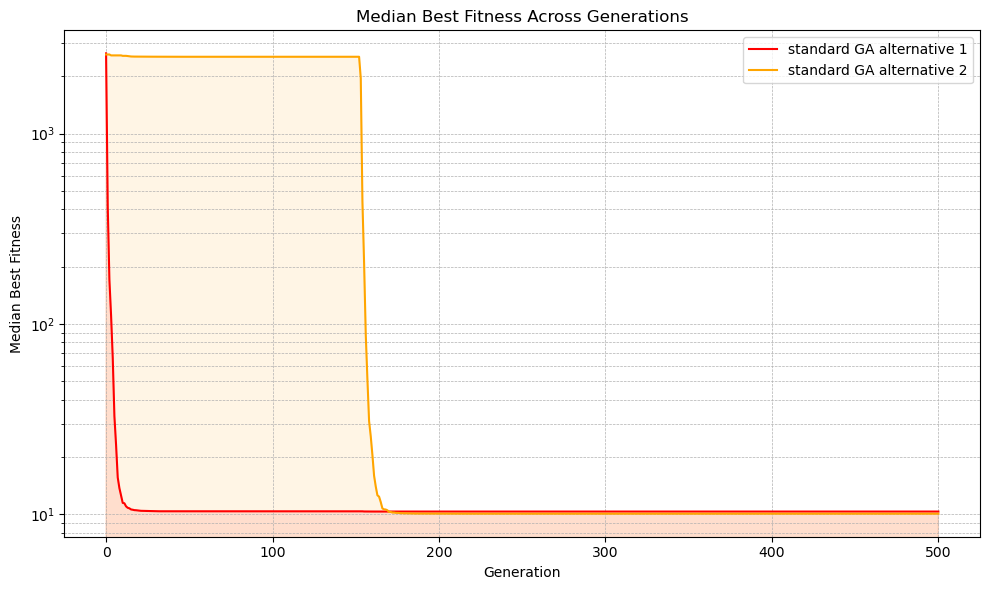

In [ ]:
# --- Fitness plot with log y-axis ---
plt.figure(figsize=(10, 6))
for df, color, label in zip(dfs, fitness_colors, labels):
    plt.plot(df['generation'], df['median_best_fitness'], label=label, color=color)
    plt.fill_between(df['generation'], df['median_best_fitness'], alpha=0.1, color=color)
plt.xlabel('Generation')
plt.ylabel('Median Best Fitness')
plt.title('Median Best Fitness Across Generations')
plt.yscale('log')  # Log scale for y-axis
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### statistical comparison between all standard models

### Kruskal-Wallis for comparison all against all

In [ ]:
from scipy.stats import kruskal

h_stat, p_value = kruskal(standard_GA_last_elites, standard_GA_alternative2_last_elites, standard_GA_alternative1_last_elites)
print(f"Kruskal–Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Kruskal–Wallis H-statistic: 3.5329
P-value: 0.1709
